# Review

In [2]:
import pandas as pd

# This overrides how Colab displays Pandas Series.
#from google.colab import _reprs
#_reprs.disable_pandas_series_repr()

df = pd.read_csv("https://datasci112.stanford.edu/data/titanic.csv", index_col="name")
df

,pclass,survived,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
name,,,,,,,,,,,,,
"Allen, Miss. Elisabeth Walton",1,1,female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
"Allison, Master. Hudson Trevor",1,1,male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
"Allison, Miss. Helen Loraine",1,0,female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
"Allison, Mr. Hudson Joshua Creighton",1,0,male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",1,0,female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Zabour, Miss. Hileni",3,0,female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
"Zabour, Miss. Thamine",3,0,female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
"Zakarian, Mr. Mapriededer",3,0,male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN


In [3]:
df["pclass"].value_counts().sort_index()

,count
pclass,
1,323
2,277
3,709


In [ ]:
df["pclass"].value_counts().sort_index().plot.bar()

# Two or More Categorical Variables

Note that we selected a single column by passing the column name as a key to the `DataFrame`. The result is a one-dimensional _pandas_ object called a `Series`.

In [4]:
pclass = df["pclass"]

In [5]:
type(pclass)

pandas.core.series.Series

The `Series` generally has a name (because it is often a column of a `DataFrame`). It also retains the `.index`.

In [6]:
pclass.name

'pclass'

In [7]:
pclass.index

Index(['Allen, Miss. Elisabeth Walton', 'Allison, Master. Hudson Trevor',
       'Allison, Miss. Helen Loraine', 'Allison, Mr. Hudson Joshua Creighton',
       'Allison, Mrs. Hudson J C (Bessie Waldo Daniels)',
       'Anderson, Mr. Harry', 'Andrews, Miss. Kornelia Theodosia',
       'Andrews, Mr. Thomas Jr',
       'Appleton, Mrs. Edward Dale (Charlotte Lamson)',
       'Artagaveytia, Mr. Ramon',
       ...
       'Yasbeck, Mr. Antoni', 'Yasbeck, Mrs. Antoni (Selini Alexander)',
       'Youseff, Mr. Gerious', 'Yousif, Mr. Wazli', 'Yousseff, Mr. Gerious',
       'Zabour, Miss. Hileni', 'Zabour, Miss. Thamine',
       'Zakarian, Mr. Mapriededer', 'Zakarian, Mr. Ortin',
       'Zimmerman, Mr. Leo'],
      dtype='object', name='name', length=1309)

We can also select multiple columns by passing a list of column names as the key. The result is another `DataFrame`.

In [8]:
df[["pclass", "survived"]]

,pclass,survived
name,,
"Allen, Miss. Elisabeth Walton",1,1
"Allison, Master. Hudson Trevor",1,1
"Allison, Miss. Helen Loraine",1,0
"Allison, Mr. Hudson Joshua Creighton",1,0
"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",1,0
...,...,...
"Zabour, Miss. Hileni",3,0
"Zabour, Miss. Thamine",3,0
"Zakarian, Mr. Mapriededer",3,0


To summarize multiple categorical variables, we report the counts of every possible combination of categories.

We can use the `.value_counts()` method of `DataFrame`.

In [9]:
joint = df[["pclass", "survived"]].value_counts()
joint

,,count
pclass,survived,
3,0,528
1,1,200
3,1,181
2,0,158
1,0,123
2,1,119


It is again a `Series`. Let's look at the `.index` and `.columns`:

In [10]:
joint.name

'count'

Its index are *pairs* of different values of `pclass` and `survived`.

In [11]:
joint.index

MultiIndex([(3, 0),
            (1, 1),
            (3, 1),
            (2, 0),
            (1, 0),
            (2, 1)],
           names=['pclass', 'survived'])

Let's make this information easier to read by arranging one variable along the rows and
the other along the columns. This is called a crosstab.

In [14]:
(df[["pclass", "survived"]].value_counts().
 unstack())

survived,0,1
pclass,,
1,123,200
2,158,119
3,528,181


From a crosstab, we can make a barplot to visualize the data.

<Axes: xlabel='pclass'>

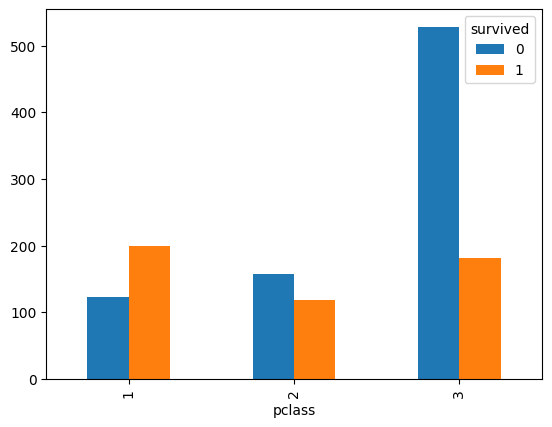

In [15]:
(df[["pclass", "survived"]].value_counts().
 unstack().
 plot.bar())

Let's look at what happens when we switch the columns? The `.unstack()` method depends on the *order* of the columns we selected.

<Axes: xlabel='survived'>

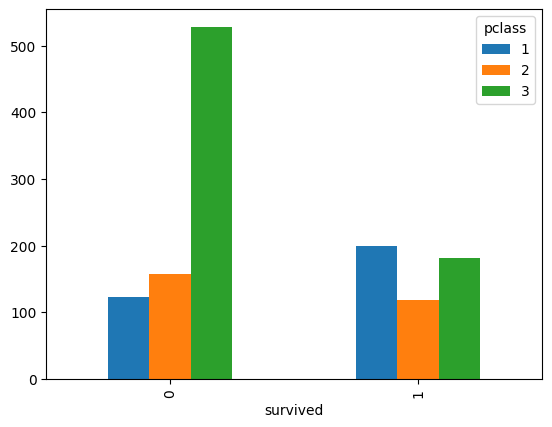

In [16]:
(df[["survived", "pclass"]].value_counts().
 unstack().
 plot.bar())

How could we recover the counts for each individual variable from a crosstab?

We could sum over the columns (across each row) to obtain the counts for **pclass**.

In [24]:
crosstab = df[["pclass", "survived"]].value_counts().unstack()
crosstab.sum(axis="columns")

,0
pclass,
1,323
2,277
3,709


...or sum over the rows (down each column) to obtain the counts for **survived**...

In [25]:
crosstab.sum(axis="rows")

,0
survived,
0,809
1,500


# Proportions and Probabilities

Instead of counts, it can be useful to report  proportions, where we normalize by the total.

In [36]:
df["pclass"].value_counts() / df.shape[0]

,count
pclass,
3,0.541635
1,0.246753
2,0.211612


## Choosing passengers at random

In [41]:
n = 10000
df['pclass'].sample(n=n, replace=True).value_counts() / n

,count
pclass,
3,0.5410
1,0.2443
2,0.2147


# Joint and Conditional Distributions

We can also calculate the distribution of multiple variables, called a **joint distribution**.

In [42]:
df[["pclass", "survived"]].value_counts().unstack() / df.shape[0]

survived,0,1
pclass,,
1,0.093965,0.152788
2,0.120703,0.090909
3,0.403361,0.138273


<Axes: xlabel='pclass'>

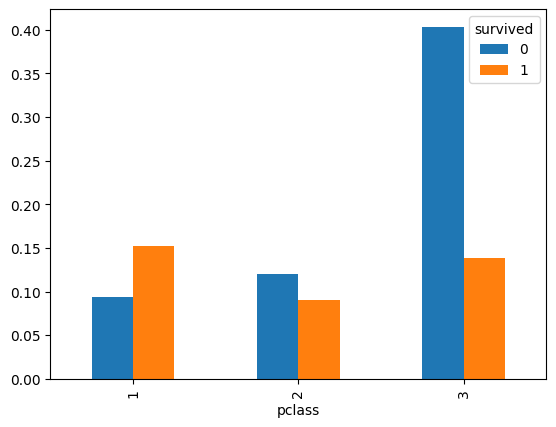

In [43]:
((df[["pclass", "survived"]].value_counts().unstack() / df.shape[0]).
 plot.bar())

If we want to compare survival across the classes, we should divide by the total in each class.

In [47]:
crosstab = df[["pclass", "survived"]].value_counts().unstack()
pclass_marginal = crosstab.sum(axis="columns")
pclass_marginal

,0
pclass,
1,323
2,277
3,709


In [50]:
pclass_marginal = crosstab.sum(axis="columns")
crosstab.divide(pclass_marginal, axis="rows")

survived,0,1
pclass,,
1,0.380805,0.619195
2,0.570397,0.429603
3,0.744711,0.255289


## What do we mean by conditional?

In [51]:
n, idx = 10000, 1
pclass_ = df[df['pclass'] == idx]
pclass_['survived'].sample(n=n, replace=True).value_counts().sort_index() / n

,count
survived,
0,0.3851
1,0.6149


### Exercise

Compare class distributions across the survival status.

To visualize a conditional distribution, we can make a grouped bar plot...

<Axes: xlabel='pclass'>

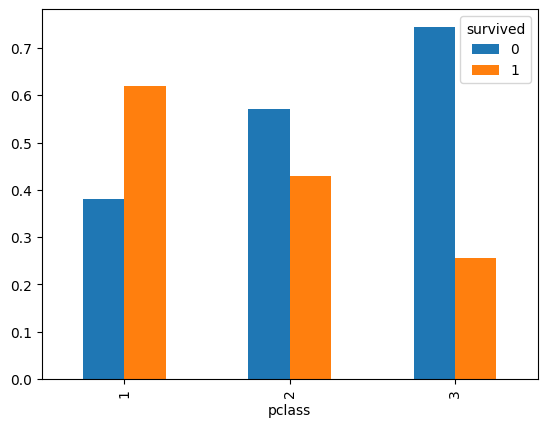

In [52]:
(crosstab.divide(pclass_marginal, axis="rows").
 plot.bar())

...but it is better to make a stacked bar plot.

<Axes: xlabel='pclass'>

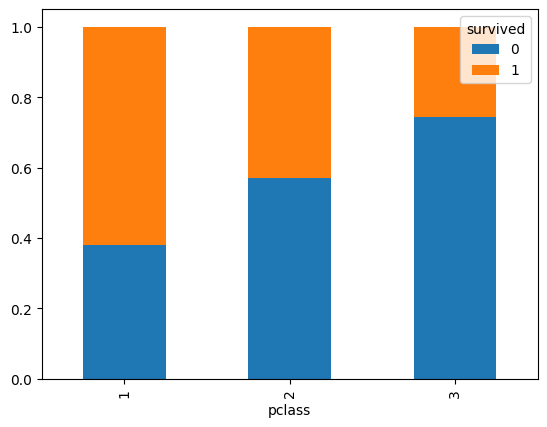

In [53]:
(crosstab.divide(pclass_marginal, axis="rows").
 plot.bar(stacked=True))